---
title: "Normalization, identification of most variable genes"
author: "Mary Piper, Meeta Mistry, Radhika Khetani, Jihe Liu"
date: November 30, 2022
---

Approximate time: 90 minutes

## Learning Objectives:

* Discuss why normalizing counts is necessary for accurate comparison between cells
* Describe different normalization approaches
* Evaluate the effects from any unwanted sources of variation and correct for them


# Single-cell RNA-seq: Normalization and regressing out unwanted variation

Now that we have our high quality cells, we can explore our data and see if we are able to identify any sources of unwanted variation. Depending on what we observe, we will utilize that information when performing variance stabilization using SCTransform but also to regress out the effects of any covariates that have an effect on our data.

<p align="center">
<img src="../img/sc_workflow_2022.jpg" width="630">
</p>

***

_**Goals:**_ 
 
 - _To accurately **normalize the gene expression values** to account for differences in sequencing depth and overdispersed count values._
 - _To **identify the most variant genes** likely to be indicative of the different cell types present._

_**Challenges:**_
 
 - _**Checking and removing unwanted variation** so that we do not have cells clustering by artifacts downstream_

_**Recommendations:**_
 
 - _Have a good idea of your expectations for the **cell types to be present** prior to performing the clustering. Know whether you expect cell types of low complexity or higher mitochondrial content AND whether the cells are differentiating_
 - _**Regress out** number of UMIs (default using sctransform), mitochondrial content, and cell cycle, if needed and appropriate for experiment, so not to drive clustering downstream_
 
***

## Normalization
An essential first step in the majority of mRNA expression analyses is normalization, whereby systematic variations are adjusted for to **make expression counts comparable across genes and/or samples**. The counts of mapped reads for each gene is proportional to the expression of RNA ("interesting") in addition to many other factors ("uninteresting"). Normalization is the process of adjusting raw count values to account for the "uninteresting" factors. 

The main factors often considered during normalization are:
 
 - **Sequencing depth:** Accounting for sequencing depth is necessary for comparison of gene expression between cells. In the example below, each gene appears to have doubled in expression in cell 2, however this is a consequence of cell 2 having twice the sequencing depth.

<p align="center">
<img src="../img/sequencing_depth.png" width="400">
</p>

Each cell in scRNA-seq will have a differing number of reads associated with it. So to accurately compare expression between cells, it is necessary to normalize for sequencing depth.
 
 - **Gene length:** Accounting for gene length is necessary for comparing expression between different genes within the same cell. The number of reads mapped to a longer gene can appear to have equal count/expression as a shorter gene that is more highly expressed. 
 
<p align="center"> 
<img src="../img/length_of_gene.png" width="400">
</p>

::: callout-note
If using a 3' or 5' droplet-based method, the length of the gene will not affect the analysis because only the 5' or 3' end of the transcript is sequenced.* However, if using full-length sequencing, the transcript length should be accounted for.
:::

### Methods for scRNA-seq normalization

Various methods have been developed specifically for scRNA-seq normalization. Some **simpler methods resemble what we have seen with bulk RNA-seq**; the application of **global scale factors** adjusting for a count-depth relationship that is assumed common across all genes. However, if those assumptions are not true then this basic normalization can lead to over-correction for lowly and moderately expressed genes and, in some cases, under-normalization of highly expressed genes ([Bacher R et al, 2017](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5473255/)). **More complex methods will apply correction on a per-gene basis.** In this lesson we will explore both approaches.

Regardless of which method is used for normalization, it can be helpful to **think of it as a two-step process** (even though it is often described as a single step in most papers). The first is a scaling step and the second is a transformation.

**1. Scaling**

The first step in normalization is to **multiply each UMI count by a cell specific factor to get all cells to have the same UMI counts**. Why would we want to do this? Different cells have different amounts of mRNA; this could be due to differences between cell types or variation within the same cell type depending on how well the chemistry worked in one drop versus another. In either case, we are not interested in comparing these absolute counts between cells. Instead we are interested in comparing concentrations, and scaling helps achieve this.


**2. Transformation**

The next step is a transformation, and it is at this step where we can distinguish the simpler versus complex methods as mentioned above.

**Simple transformations** are those which apply the same function to each individual measurement. Common examples include a **log transform** (which is applied in the original Seurat workflow), or a square root transform (less commonly used).


##  Explore sources of unwanted variation

The most common biological data correction (or source of "uninteresting" variation) in single cell RNA-seq is the effects of the cell cycle on the transcriptome. We need to explore the data and see if we observe any effects in our data.   

### Set-up

Let's start by creating a new script for the normalization and integration steps. Create a new script (File -> New File -> R script), and save it as `SCT_integration_analysis.R`.

For the remainder of the workflow we will be mainly using functions available in the Seurat package. Therefore, we need to load the Seurat library in addition to the tidyverse library and a few others listed below. 

In [7]:
# Single-cell RNA-seq - normalization

import scanpy as sc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

adata_filt = sc.read_h5ad("../results/04_filter.h5ad")

Before we make any comparisons across cells, we will **apply a simple normalization.** This is solely for the purpose of exploring the sources of variation in our data.

In [8]:
# Saving count data
adata_filt.layers["counts"] = adata_filt.X.copy()

# Normalizing to median total counts
adata_filt.layers['median'] = adata_filt.layers['counts'].copy()
sc.pp.normalize_total(adata_filt, layer='median')

# Logarithmize the data
adata_filt.layers['log'] = adata_filt.layers['median'].copy()
sc.pp.log1p(adata_filt, layer='log')

Let's investigate what changes have been made to our scanpy object in the process of running each of these functions. Ideally we would expect to see that we have new layers in our object that correspond with our raw counts, normalized counts, and log-scaled normalized counts.

In [9]:
adata_filt.layers

Layers with keys: counts, median, log

## Highly Variable Genes

To perform any dimensionality reduction, we need to **calculate our most highly variable genes**. 

Highly variable gene selection is extremely important since many downstream steps are computed only on these genes. Scanpy allows us to access the ranked highly variable genes with the `highly_variable_genes()` function. 

The parameters we are specifying refer to:

- `layer`: Which count matrix to use, if `.X` is not the matrix we want to use.
- `n_top_genes`: Number of highly-variable genes to keep.
- `batch_key`: If specified, highly-variable genes are selected within each batch separately and merged. This simple process avoids the selection of batch-specific genes and acts as a lightweight batch correction method.

In [27]:
# HVG
sc.pp.highly_variable_genes(adata_filt, layer='counts', 
                            flavor='seurat_v3', n_top_genes=4500, 
                            batch_key='sample')

We now have generate new columns in our `var` slot:

- `highly_variable`:
- `highly_variable_rank`:
- `means`:
- `variances`:
- `variances_norm`:
- `highly_variable_nbatches`:

In [28]:
adata_filt.var.head()

,gene_ids,feature_types,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mito,log1p_mean_counts,log1p_total_counts,n_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
AL627309.1,ENSG00000238009,Gene Expression,12,0.000382,99.961837,12.0,False,0.000382,2.564949,12.0,False,NaN,0.000405,0.000405,0.932602,0
AL669831.5,ENSG00000237491,Gene Expression,99,0.003212,99.685155,101.0,False,0.003207,4.624973,99.0,False,NaN,0.003341,0.003465,0.920303,0
LINC00115,ENSG00000225880,Gene Expression,177,0.005915,99.437095,186.0,False,0.005898,5.231109,170.0,False,3875.0,0.005738,0.006447,0.964424,1
FAM41C,ENSG00000230368,Gene Expression,136,0.004389,99.567485,138.0,False,0.004379,4.934474,134.0,False,NaN,0.004523,0.004637,0.896534,0
NOC2L,ENSG00000188976,Gene Expression,2019,0.069934,93.579061,2199.0,False,0.067597,7.696213,2139.0,False,NaN,0.072193,0.082442,0.904630,0


To visualize the variable genes we calculated, we can make use of the scanpy's `pl.highly_variable_genes()`.

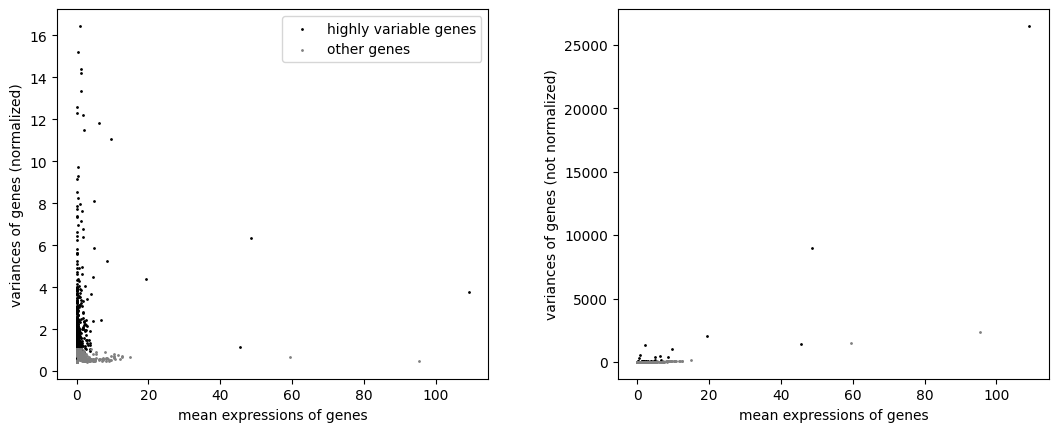

In [31]:
sc.pl.highly_variable_genes(adata_filt)

Alternatively, we can create our own custom plot to represent this data. Where we can  visualize the dispersion of all genes, showing a gene's average expression across all cells on the x-axis and variance on the y-axis. Ideally we want to use genes that have high variance since this can indicate a change in expression depending on populations of cells. Adding labels using the `text()` helps us understand which genes will be driving shape of our data.

/var/folders/qb/pppkhh997tl5mc721j34g6qh0000gn/T/ipykernel_56172/3892437044.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sns.scatterplot(x=x[adata_filt.uns['id_hvg']], y=y[adata_filt.uns['id_hvg']], ax=ax, label='HVGs', color='r')


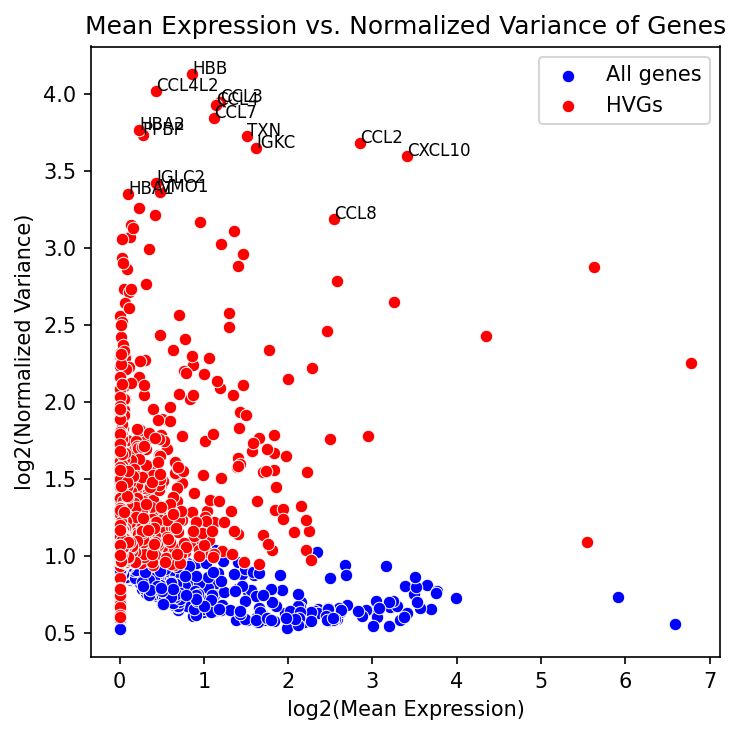

In [33]:
# Set-up the shape of the plot
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# Grab the mean and variance to use in a scatterplot
x = np.log2(adata_filt.var['means'] + 1)
y = np.log2(adata_filt.var['variances_norm'] + 1)

# Create scatterplot of ALL genes
# Color them blue ('b')
sns.scatterplot(x=x, y=y, ax=ax, label='All genes', color='b')

# Grab ONLY the highly variable genes
# Plot them on top in the color red ('r')
adata_filt.uns['id_hvg'] = np.where(adata_filt.var['highly_variable'])[0]
sns.scatterplot(x=x[adata_filt.uns['id_hvg']], y=y[adata_filt.uns['id_hvg']], ax=ax, label='HVGs', color='r')

# Set the labels 
ax.set(xlabel='log2(Mean Expression)', ylabel='log2(Normalized Variance)',
       title='Mean Expression vs. Normalized Variance of Genes')


# Take the top N variable genes and label them on the plot
N = 15
top_idx = adata_filt.var['highly_variable_rank'].nsmallest(N).index
for gene_name in top_idx:
    ax.text(x[gene_name], y[gene_name], gene_name, fontsize=8, color="black")

# Visualize the plot
plt.legend()
plt.tight_layout()
plt.show()

Now that we have calculated our highly variable genes, we can use these genes as the input for our PCA calculations.

### PCA

Principal Component Analysis (PCA) is a technique used to emphasize variation as well as similarity, and to bring out strong patterns in a dataset; it is one of the methods used for *"dimensionality reduction"*. 

::: callout-note
For a more **detailed explanation on PCA**, please [look over this lesson](06_theory_of_PCA.qmd) (adapted from StatQuests/Josh Starmer's YouTube video). We also strongly encourage you to explore the video [StatQuest's video](https://www.youtube.com/watch?v=_UVHneBUBW0) for a more thorough understanding. 
:::

Let's say you are working with a single-cell RNA-seq dataset with *12,000 cells* and you have quantified the expression of *20,000 genes*. The schematic below demonstrates how you would go from a cell x gene matrix to principal component (PC) scores for each inividual cell.

<p align="center">
<img src="../img/PCA_scrnaseq_1.png" width="900">
</p>

After the PC scores have been calculated, you are looking at a matrix of 12,000 x 12,000 that represents the information about relative gene expression in all the cells. You can select the PC1 and PC2 columns and plot that in a 2D way.

<p align="center">
<img src="../img/PCA_scrnaseq_2.png" width="600">
</p>

You can also use the PC scores from the first 40 PCs for downstream analysis like clustering, marker identification etc., since these represent the majority of the variation in the data. We will be talking a lot more about this later in this workshop.

<p align="center">
<img src="../img/PCA_scrnaseq_3.png" width="600">
</p>

::: callout-note
For datasets with a larger number of cells, only the PC1 and PC2 scores for each cell are usually plotted, or used for visualization. Since these PCs explain the most variation in the dataset, the expectation is that the cells that are more similar to each other will cluster together with PC1 and PC2.
:::

In [36]:
# Set X to be our log-normalized data
adata_filt.X = adata_filt.layers['log']
sc.tl.pca(adata_filt, n_comps=50, 
          mask_var="highly_variable")

In running this function, we have create 2 new slots in our scanpy object. The `obsm` and `varm`.

TODO: What do those stand for?

In [37]:
adata_filt

AnnData object with n_obs × n_vars = 29629 × 14167
    obs: 'n_genes', 'sample', 'n_genes_by_counts', 'total_counts', 'log10GenesPerUMI', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'mito_ratio', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mito', 'log1p_mean_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'id_hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'median', 'log'

The `X_pca` contains the scores for each cell and Principal Component.

In [39]:
adata_filt.obsm["X_pca"][1:5, 1:5]

array([[-5.464761  ,  1.4467708 ,  1.4707652 , -0.47625712],
       [-5.909921  , -1.1509504 , -1.0321858 ,  0.23781052],
       [-5.492779  , -1.847269  , -0.78184634,  0.61416733],
       [-1.3226533 , -0.02645934, -1.3118889 ,  1.8599195 ]],
      dtype=float32)

With these scores, we can plot how the cells lay on PC1 and PC2 with `pp.pca` where the `color` argument tells us which metadata column to color the cells by.

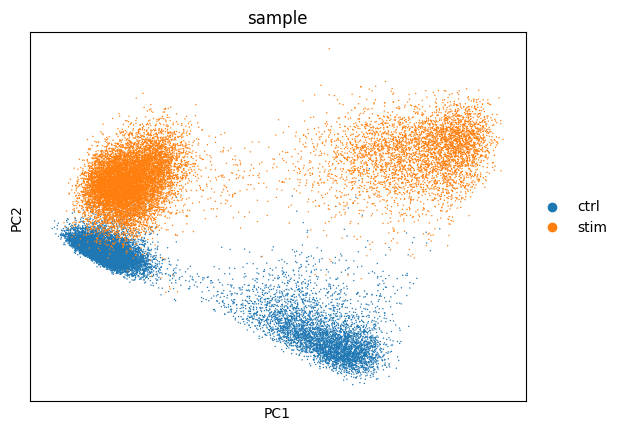

In [42]:
sc.pl.pca(adata_filt, color=["sample"])

## Evaluating effects of cell cycle 

After scoring the cells for cell cycle, we would like to **determine whether cell cycle is a major source of variation in our dataset using PCA**. 

We have provided a list of human cell cycle markers for you here. However, if you are not working with human data we have [additional materials](Aside_cell_cycle_scoring.qmd) detailing how to acquire cell cycle markers for other organisms of interest.

In [43]:
g2m_genes = [
    "NCAPD2", "ANLN", "TACC3", "HMMR", "GTSE1", "NDC80", "AURKA", "TPX2",
    "BIRC5", "G2E3", "CBX5", "RANGAP1", "CTCF", "CDCA3", "TTK", "SMC4",
    "ECT2", "CENPA", "CDC20", "NEK2", "CENPF", "TMPO", "HJURP", "CKS2",
    "DLGAP5", "PIMREG", "TOP2A", "PSRC1", "CDCA8", "CKAP2", "NUSAP1",
    "KIF23", "KIF11", "KIF20B", "CENPE", "GAS2L3", "KIF2C", "NUF2",
    "ANP32E", "LBR", "MKI67", "CCNB2", "CDC25C", "HMGB2", "CKAP2L",
    "BUB1", "CDK1", "CKS1B", "UBE2C", "CKAP5", "AURKB", "CDCA2",
    "TUBB4B", "JPT1"]

s_genes = [
    "UBR7", "RFC2", "RAD51", "MCM2", "TIPIN", "MCM6", "UNG", "POLD3",
    "WDR76", "CLSPN", "CDC45", "CDC6", "MSH2", "MCM5", "POLA1", "MCM4",
    "RAD51AP1", "GMNN", "RPA2", "CASP8AP2", "HELLS", "E2F8", "GINS2",
    "PCNA", "NASP", "BRIP1", "DSCC1", "DTL", "CDCA7", "CENPU", "ATAD2",
    "CHAF1B", "USP1", "SLBP", "RRM1", "FEN1", "RRM2", "EXO1", "CCNE2",
    "TYMS", "BLM", "PRIM1", "UHRF1"]

To assign each cell a score based on its expression of G2/M and S phase markers, we can use the function `score_genes_cell_cycle()`. This function calculates cell cycle phase scores based on canonical markers that required as input.

In [44]:
sc.tl.score_genes_cell_cycle(adata_filt, s_genes, g2m_genes)

/var/folders/qb/pppkhh997tl5mc721j34g6qh0000gn/T/ipykernel_56172/2175558622.py:1: FutureWarning: The specified parameters ('s_genes', 'g2m_genes') are no longer positional. Please specify them like `s_genes=['UBR7', 'RFC2', 'RAD51', 'MCM2', 'TIPIN', 'MCM6', 'UNG', 'POLD3', 'WDR76', 'CLSPN', 'CDC45', 'CDC6', 'MSH2', 'MCM5', 'POLA1', 'MCM4', 'RAD51AP1', 'GMNN', 'RPA2', 'CASP8AP2', 'HELLS', 'E2F8', 'GINS2', 'PCNA', 'NASP', 'BRIP1', 'DSCC1', 'DTL', 'CDCA7', 'CENPU', 'ATAD2', 'CHAF1B', 'USP1', 'SLBP', 'RRM1', 'FEN1', 'RRM2', 'EXO1', 'CCNE2', 'TYMS', 'BLM', 'PRIM1', 'UHRF1']`
  sc.tl.score_genes_cell_cycle(adata_filt, s_genes, g2m_genes)


Whenever we run a new function, it is a good idea to observer how our scanpy object changes. Since this is a score being calculated for each cell, we can take a look at the metadata to see which new columns have been generated.

In this case, we can see that the columns:

- S_score
- G2M_score
- phase

Have been added to our `obs` dataframe.

In [45]:
adata_filt.obs.head()

,n_genes,sample,n_genes_by_counts,total_counts,log10GenesPerUMI,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,mito_ratio,S_score,G2M_score,phase
AAACATACAATGCC-1_ctrl,874,ctrl,874,2344.0,0.872863,6.774224,7.760041,47.568259,59.129693,69.197952,84.044369,46.0,3.850147,1.962457,0.019625,0.005933,0.016737,G2M
AAACATACATTTCC-1_ctrl,896,ctrl,896,3125.0,0.844760,6.799056,8.047509,51.904000,63.456000,74.080000,87.328000,56.0,4.043051,1.792000,0.017920,0.003995,0.003142,S
AAACATACCAGAAA-1_ctrl,725,ctrl,725,2578.0,0.838493,6.587550,7.855157,61.947246,69.550039,78.432894,91.272304,40.0,3.713572,1.551590,0.015516,-0.013314,-0.032831,G1
AAACATACCAGCTA-1_ctrl,979,ctrl,979,3261.0,0.851262,6.887553,8.090096,52.836553,62.557498,71.879791,85.311254,45.0,3.828641,1.379945,0.013799,-0.017613,-0.001563,G1
AAACATACCATGCA-1_ctrl,362,ctrl,362,746.0,0.890686,5.894403,6.616065,53.887399,64.879357,78.284182,100.000000,16.0,2.833213,2.144772,0.021448,0.017205,-0.032109,S


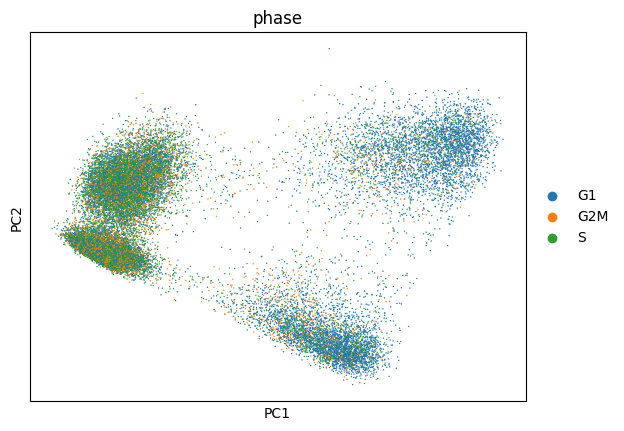

In [46]:
sc.pl.pca(adata_filt, color=["phase"])

To more clearly see the distribution for each phase, we can emphasize the `groups` and put the plots side-by-side.

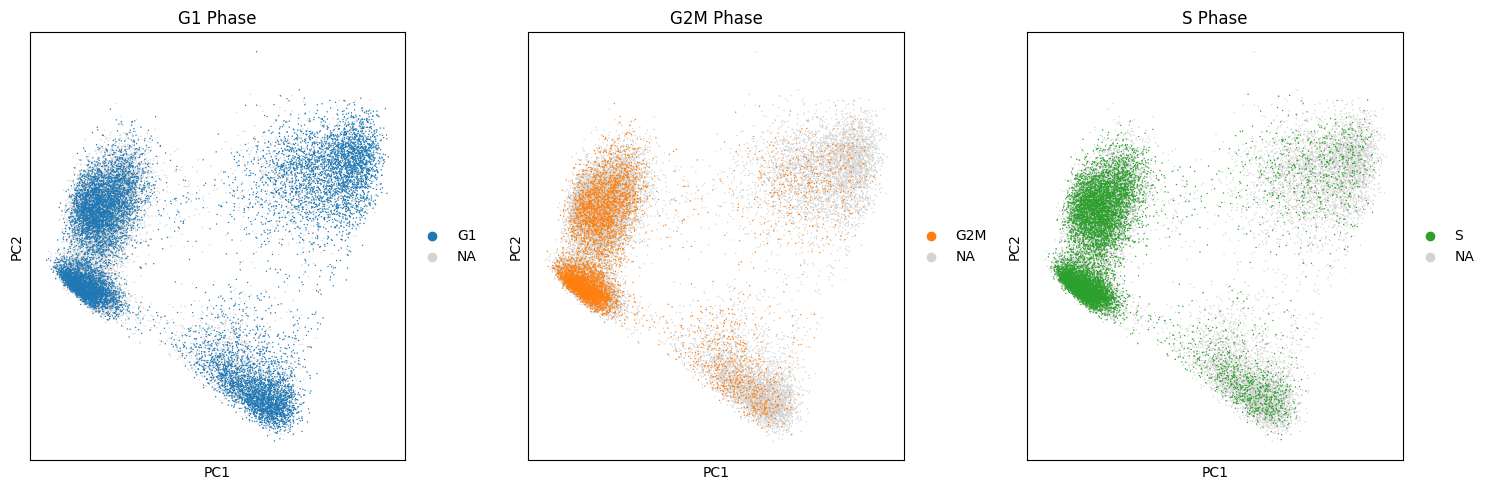

In [51]:
# Create plot with the correct dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each phase
sc.pl.pca(adata_filt, color=["phase"], groups=["G1"], ax=axes[0], 
          show=False, title="G1 Phase")
sc.pl.pca(adata_filt, color=["phase"], groups=["G2M"], ax=axes[1], 
          show=False, title="G2M Phase")
sc.pl.pca(adata_filt, color=["phase"], groups=["S"], ax=axes[2], 
          show=False, title="S Phase")

plt.tight_layout()
plt.show()

<details>
	<summary><b><i>When should cell cycle phase be regressed out?</i></b></summary>
	<br>Below are two PCA plots taken from the Seurat vignette dealing with <a href="https://satijalab.org/seurat/archive/v3.1/cell_cycle_vignette.html">Cell-Cycle Scoring and Regression</a>.<br>

 	<ul><li>This first plot is similar to what we plotted above, it is a PCA prior to regression to evaluate if the cell cycle is playing a big role in driving PC1 and PC2. Clearly, the cells are separating by cell type in this case, so the vignette suggests regressing out these effects.</li></ul>
 	<p align="center">
 	<img src="../img/cell_cycle_not_regressed.png" width="400">
 	</p>

	<ul><li>This second PCA plot is <b>post-regression</b>, and displays how effective the regression was in removing the effect we observed.</li></ul>

	<p align="center">
	<img src="../img/cell_cycle_regressed.png" width="400">
	</p>
</details>


***

::: callout-tip
# [**Exercise 1**](07_SCT_normalization-Answer_key.qmd#exercise-1)

Mitochondrial expression is another factor which can greatly influence clustering. Oftentimes, it is useful to regress out variation due to mitochondrial expression. However, if the differences in mitochondrial gene expression represent a biological phenomenon that may help to distinguish cell clusters, then we advise not regressing this out. In this exercise, we can perform a quick check similar to looking at cell cycle and decide whether or not we want to regress it out.

First, turn the mitochondrial ratio variable into a new categorical variable based on quartiles (using the code below):

In [60]:
np.percentile(adata_filt.obs["pct_counts_mito"], [0, 25, 50, 75, 100])

array([ 0.        ,  1.43786371,  1.99296606,  2.66920877, 14.46428585])